# Twitter Sentiment Analysis: Product Comparison

## 1. Setup Environment and Libraries

In [ ]:
# Install dependencies
!pip install pandas matplotlib seaborn textblob nltk scikit-learn
print("Libraries installed successfully!")

Libraries installed successfully!


In [ ]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

print("Core libraries imported successfully!")

Core libraries imported successfully!


In [ ]:
# Ensure NLTK resources are available
nltk.data.path = ['/root/nltk_data']

try:
    nltk.data.find('sentiment/vader_lexicon.zip')
except LookupError:
    nltk.download('vader_lexicon')
try:
    nltk.data.find('tokenizers/punkt.zip')
except LookupError:
    nltk.download('punkt')

try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')
try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')

nltk.download('punkt', quiet=False)
nltk.download('punkt_tab', quiet=False)

print("NLTK data checked/downloaded successfully!")

NLTK data checked/downloaded successfully!


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


## 2. Load Dataset

In [ ]:
# Load dataset
try:
    df = pd.read_csv('/Dataset/twitter_dataset.csv')
    print("Dataset loaded successfully!")
    display(df.head())
except FileNotFoundError:
    print("Error: 'twitter_dataset.csv' not found. Please ensure the file is uploaded to /Dataset/.")
    df = pd.DataFrame()

Dataset loaded successfully!


,id,tweet
0,1,#fingerprint #Pregnancy Test https://goo.gl/h1...
1,2,Finally a transparant silicon case ^^ Thanks t...
2,3,We love this! Would you go? #talk #makememorie...
3,4,I'm wired I know I'm George I was made that wa...
4,5,What amazing service! Apple won't even talk to...


## 3. Define Functions

In [ ]:
# Text cleaning
def clean_text(text):
    text = re.sub(r'@[A-Za-z0-9_]+', '', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'RT[\s]+', '', text)
    text = re.sub(r'https?://\S+', '', text)
    return text

# TextBlob sentiment helpers
def get_textblob_sentiment(text):
    analysis = TextBlob(text)
    if analysis.sentiment.polarity > 0:
        return 'Positive'
    elif analysis.sentiment.polarity < 0:
        return 'Negative'
    else:
        return 'Neutral'

def get_textblob_polarity(text):
    return TextBlob(text).sentiment.polarity

# VADER sentiment helpers
sia = SentimentIntensityAnalyzer()

def get_vader_compound(text):
    return sia.polarity_scores(text)['compound']

def get_vader_sentiment(compound_score):
    if compound_score >= 0.05:
        return 'Positive'
    elif compound_score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

# Combined sentiment helpers
def get_combined_sentiment_score(textblob_polarity, vader_compound):
    return (textblob_polarity + vader_compound) / 2

def get_final_sentiment(combined_score):
    if combined_score >= 0.05:
        return 'Positive'
    elif combined_score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

print("Analysis functions defined.")

Analysis functions defined.


## 4. Apply Analysis Functions to Dataset

In [ ]:
# Apply sentiment pipeline
if not df.empty:
    tweet_column = None
    for col in ['tweet', 'text', 'Tweet', 'Text', 'full_text']:
        if col in df.columns:
            tweet_column = col
            break

    if tweet_column is None:
        print("Could not find a 'tweet' or 'text' column. Please check dataset.")
    else:
        print(f"Using column '{tweet_column}' for sentiment analysis.")
        df['cleaned_tweet'] = df[tweet_column].apply(clean_text)

        df['textblob_polarity'] = df['cleaned_tweet'].apply(get_textblob_polarity)
        df['textblob_sentiment'] = df['textblob_polarity'].apply(lambda x: 'Positive' if x > 0 else ('Negative' if x < 0 else 'Neutral'))

        df['vader_compound'] = df['cleaned_tweet'].apply(get_vader_compound)
        df['vader_sentiment'] = df['vader_compound'].apply(get_vader_sentiment)

        df['combined_sentiment_score'] = df.apply(lambda row: get_combined_sentiment_score(row['textblob_polarity'], row['vader_compound']), axis=1)
        df['final_sentiment'] = df['combined_sentiment_score'].apply(get_final_sentiment)

        print("Dataset cleaned and sentiment scores calculated.")
        display(df[['cleaned_tweet', 'textblob_polarity', 'textblob_sentiment', 'vader_compound', 'vader_sentiment', 'combined_sentiment_score', 'final_sentiment']].head())
else:
    print("DataFrame is empty, skipping.")

Using column 'tweet' for sentiment analysis.
Dataset cleaned and sentiment scores calculated.


,cleaned_tweet,textblob_polarity,textblob_sentiment,vader_compound,vader_sentiment,combined_sentiment_score,final_sentiment
0,fingerprint Pregnancy Test android apps beaut...,0.675000,Positive,0.7845,Positive,0.729750,Positive
1,Finally a transparant silicon case ^^ Thanks t...,0.233333,Positive,0.8519,Positive,0.542617,Positive
2,We love this! Would you go? talk makememories ...,0.625000,Positive,0.8122,Positive,0.718600,Positive
3,I'm wired I know I'm George I was made that wa...,0.375000,Positive,0.5994,Positive,0.487200,Positive
4,What amazing service! Apple won't even talk to...,-0.125000,Negative,0.5080,Positive,0.191500,Positive


## 5. Overall Sentiment Analysis and Visualization

In [ ]:
# Sentiment summary stats
if not df.empty and 'final_sentiment' in df.columns:
    sentiment_counts = df['final_sentiment'].value_counts(normalize=True) * 100
    print("\nOverall Sentiment Distribution (Final Sentiment):")
    print(sentiment_counts)

    avg_combined_score = df['combined_sentiment_score'].mean()
    print(f"\nAverage Combined Sentiment Score: {avg_combined_score:.4f}")

    print("\nTop 5 Most Positive Tweets:")
    display(df.sort_values(by='combined_sentiment_score', ascending=False)[['cleaned_tweet', 'combined_sentiment_score']].head())

    print("\nTop 5 Most Negative Tweets:")
    display(df.sort_values(by='combined_sentiment_score', ascending=True)[['cleaned_tweet', 'combined_sentiment_score']].head())
else:
    print("DataFrame is empty or sentiment columns not found, skipping.")


Overall Sentiment Distribution (Final Sentiment):
final_sentiment
Positive    62.675985
Negative    20.206624
Neutral     17.117391
Name: proportion, dtype: float64

Average Combined Sentiment Score: 0.2061

Top 5 Most Positive Tweets:


,cleaned_tweet,combined_sentiment_score
850,Apple has saved my iTunes account. The guys fr...,0.98375
2024,"Happy Birthday, Selina! :D :D :D birthday kitt...",0.98085
5358,Yey! Thank you beb! I love you!!! Mwah! valent...,0.98055
8679,May the divine blessings of Allah bring you ho...,0.97540
2454,My Best Friend my best friend in cilacap miss ...,0.96745



Top 5 Most Negative Tweets:


,cleaned_tweet,combined_sentiment_score
951,yousuck Worst mobiles with worst service with...,-0.96155
9231,Quit bitching hoes. getyalife bitches hoesbeli...,-0.94045
6180,I hated my iPhone 5! Worst thing ever. Raisin...,-0.93110
1637,My iPhone just deleted all my contacts!!!! I h...,-0.92720
4075,So Apple have evaded tax as well... just anoth...,-0.92010


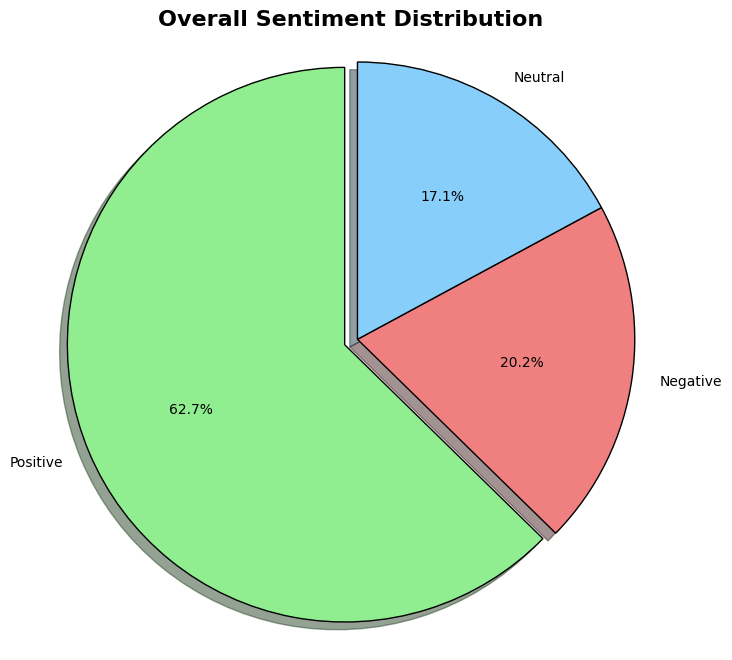

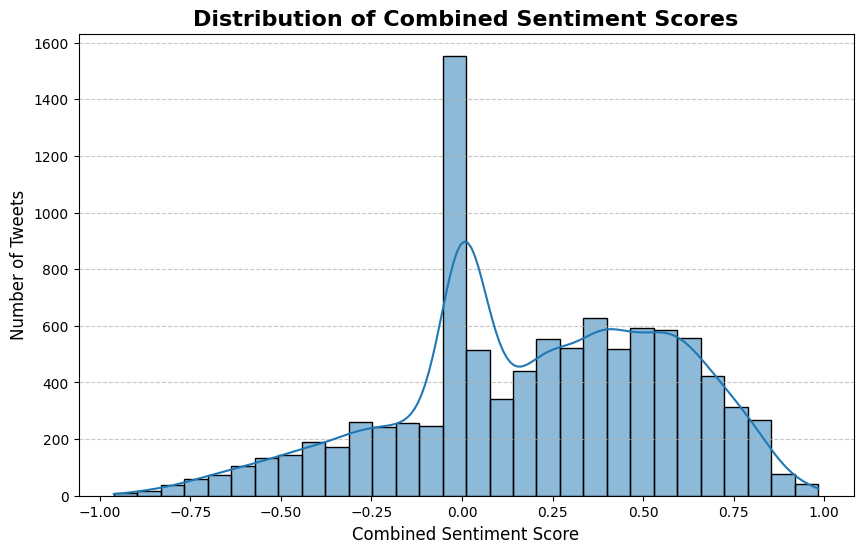

In [ ]:
# Sentiment plots
if not df.empty and 'final_sentiment' in df.columns:
    sentiment_counts = df['final_sentiment'].value_counts()
    colors = {'Positive': 'lightgreen', 'Negative': 'lightcoral', 'Neutral': 'lightskyblue'}
    explode = [0.05 if sentiment == sentiment_counts.idxmax() else 0 for sentiment in sentiment_counts.index]

    fig1, ax1 = plt.subplots(figsize=(8, 8))
    ax1.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', startangle=90, colors=[colors[s] for s in sentiment_counts.index], explode=explode, shadow=True, wedgeprops={'edgecolor': 'black'})
    ax1.axis('equal')
    plt.title('Overall Sentiment Distribution', fontsize=16, fontweight='bold')
    plt.show()

    fig2, ax2 = plt.subplots(figsize=(10, 6))
    sns.histplot(df['combined_sentiment_score'], bins=30, kde=True, ax=ax2)
    ax2.set_title('Distribution of Combined Sentiment Scores', fontsize=16, fontweight='bold')
    ax2.set_xlabel('Combined Sentiment Score', fontsize=12)
    ax2.set_ylabel('Number of Tweets', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

else:
    print("DataFrame is empty or sentiment columns not found, skipping.")

## 6. Topic Modeling

In [ ]:
# Topic modeling preprocessing
stop_words = set(stopwords.words('english'))
custom_stop_words = ['amp', 'new', 'get', 'like', 'just', 'can', 'dont', 'go', 'us', 'one', 'want', 'said']
stop_words.update(custom_stop_words)

lemmatizer = WordNetLemmatizer()

# Text preprocessing for topic modeling
def preprocess_for_topic_modeling(text):
    tokens = word_tokenize(text.lower())
    filtered_tokens = [lemmatizer.lemmatize(word) for word in tokens if word.isalpha() and word not in stop_words]
    return " ".join(filtered_tokens)

if not df.empty and 'cleaned_tweet' in df.columns:
    df['preprocessed_tweet'] = df['cleaned_tweet'].apply(preprocess_for_topic_modeling)
    print("Tweets preprocessed for topic modeling.")
    display(df[['cleaned_tweet', 'preprocessed_tweet']].head())
else:
    print("DataFrame is empty or 'cleaned_tweet' column not found, skipping topic modeling preprocessing.")

Tweets preprocessed for topic modeling.


,cleaned_tweet,preprocessed_tweet
0,fingerprint Pregnancy Test android apps beaut...,fingerprint pregnancy test android apps beauti...
1,Finally a transparant silicon case ^^ Thanks t...,finally transparant silicon case thanks uncle ...
2,We love this! Would you go? talk makememories ...,love would talk makememories unplug relax ipho...
3,I'm wired I know I'm George I was made that wa...,wired know george made way iphone cute daventr...
4,What amazing service! Apple won't even talk to...,amazing service apple wo even talk question un...


In [ ]:
# Topic modeling with TF-IDF + NMF
if not df.empty and 'preprocessed_tweet' in df.columns and not df['preprocessed_tweet'].empty:
    tfidf_vectorizer = TfidfVectorizer(max_df=0.90, min_df=5, stop_words='english', ngram_range=(1,1))
    tfidf = tfidf_vectorizer.fit_transform(df['preprocessed_tweet'])

    n_components = 5

    nmf_model = NMF(n_components=n_components, random_state=42, init='nndsvda', max_iter=200)
    nmf_topic_features = nmf_model.fit_transform(tfidf)

    print(f"NMF model trained with {n_components} components.")

    feature_names = tfidf_vectorizer.get_feature_names_out()
    print("\nTop words per topic:")
    for topic_idx, topic in enumerate(nmf_model.components_):
        top_words_idx = topic.argsort()[:-10 - 1:-1]
        top_words = [feature_names[i] for i in top_words_idx]
        print(f"Topic {topic_idx + 1}: {', '.join(top_words)}")

    df['dominant_topic'] = nmf_topic_features.argmax(axis=1)
    print("\nDominant topic assigned to each tweet.")
    display(df[['cleaned_tweet', 'dominant_topic']].head())

else:
    print("Skipping TF-IDF vectorization and NMF as preprocessed data is not available or empty.")

NMF model trained with 5 components.

Top words per topic:
Topic 1: follow, gain, sougofollow, rts, follower, iphone, ff, followback, retweet, sup
Topic 2: apple, phone, io, update, suck, ipod, itunes, fuck, hate, mac
Topic 3: ipad, funny, fail, health, tech, lol, fashion, news, photography, iphone
Topic 4: samsung, phone, galaxy, got, finally, sony, android, note, happy, birthday
Topic 5: iphone, love, case, life, day, cute, instagram, today, photo, instagood

Dominant topic assigned to each tweet.


,cleaned_tweet,dominant_topic
0,fingerprint Pregnancy Test android apps beaut...,4
1,Finally a transparant silicon case ^^ Thanks t...,3
2,We love this! Would you go? talk makememories ...,4
3,I'm wired I know I'm George I was made that wa...,4
4,What amazing service! Apple won't even talk to...,1


## 7. Comparative Sentiment Analysis: iPhone vs. Samsung

Comparison DataFrame created. Displaying head:


,cleaned_tweet,dominant_topic,product_category,final_sentiment
0,fingerprint Pregnancy Test android apps beaut...,4,iPhone,Positive
2,We love this! Would you go? talk makememories ...,4,iPhone,Positive
3,I'm wired I know I'm George I was made that wa...,4,iPhone,Positive
4,What amazing service! Apple won't even talk to...,1,iPhone,Positive
7,New Type C charger cable UK … bay Amazon etsy...,1,iPhone,Negative



Sentiment Distribution (Percentage) for iPhone vs. Samsung:


final_sentiment,Negative,Neutral,Positive
product_category,,,
Samsung,14.124783,16.854419,69.020797
iPhone,23.573863,17.202549,59.223589


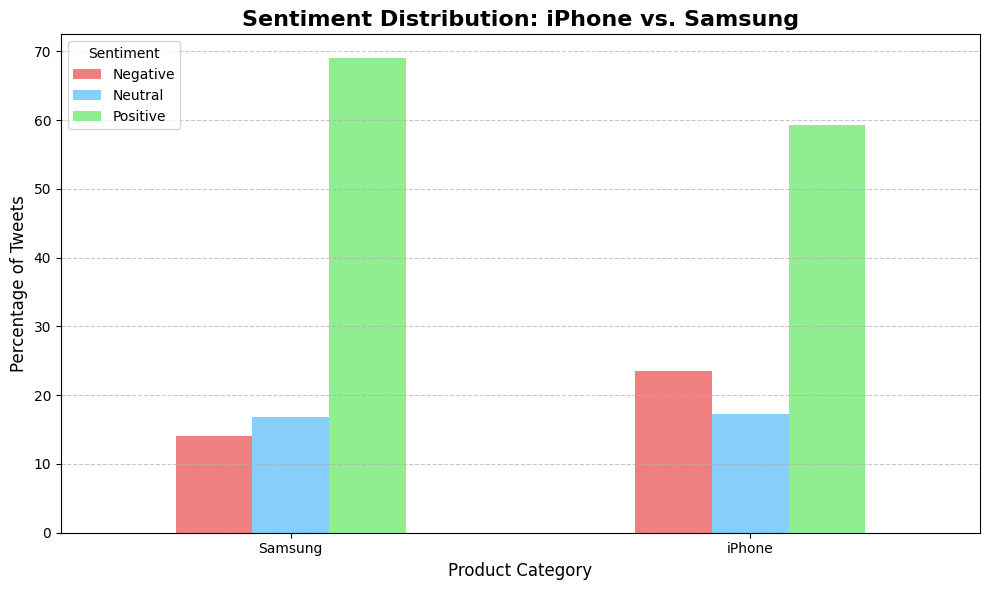

In [ ]:
# Compare iPhone vs. Samsung sentiment
if not df.empty and 'dominant_topic' in df.columns and 'final_sentiment' in df.columns:
    iphone_topics = [1, 4]
    samsung_topics = [3]

    iphone_df = df[df['dominant_topic'].isin(iphone_topics)].copy()
    iphone_df['product_category'] = 'iPhone'

    samsung_df = df[df['dominant_topic'].isin(samsung_topics)].copy()
    samsung_df['product_category'] = 'Samsung'

    comparison_df = pd.concat([iphone_df, samsung_df])

    if not comparison_df.empty:
        print("Comparison DataFrame created. Displaying head:")
        display(comparison_df[['cleaned_tweet', 'dominant_topic', 'product_category', 'final_sentiment']].head())

        sentiment_comparison = comparison_df.groupby(['product_category', 'final_sentiment']).size().unstack(fill_value=0)
        sentiment_comparison_percentage = sentiment_comparison.apply(lambda x: x / x.sum() * 100, axis=1)

        print("\nSentiment Distribution (Percentage) for iPhone vs. Samsung:")
        display(sentiment_comparison_percentage)

        sentiment_comparison_percentage.plot(kind='bar', figsize=(10, 6), color={'Positive': 'lightgreen', 'Negative': 'lightcoral', 'Neutral': 'lightskyblue'})
        plt.title('Sentiment Distribution: iPhone vs. Samsung', fontsize=16, fontweight='bold')
        plt.xlabel('Product Category', fontsize=12)
        plt.ylabel('Percentage of Tweets', fontsize=12)
        plt.xticks(rotation=0)
        plt.legend(title='Sentiment')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

    else:
        print("No relevant tweets found for iPhone or Samsung to perform comparative analysis.")
else:
    print("DataFrame is empty or required columns for comparative analysis not found.")

### Average Sentiment Score: iPhone vs. Samsung


Average Combined Sentiment Score for iPhone vs. Samsung:


,product_category,combined_sentiment_score
0,Samsung,0.255133
1,iPhone,0.183782


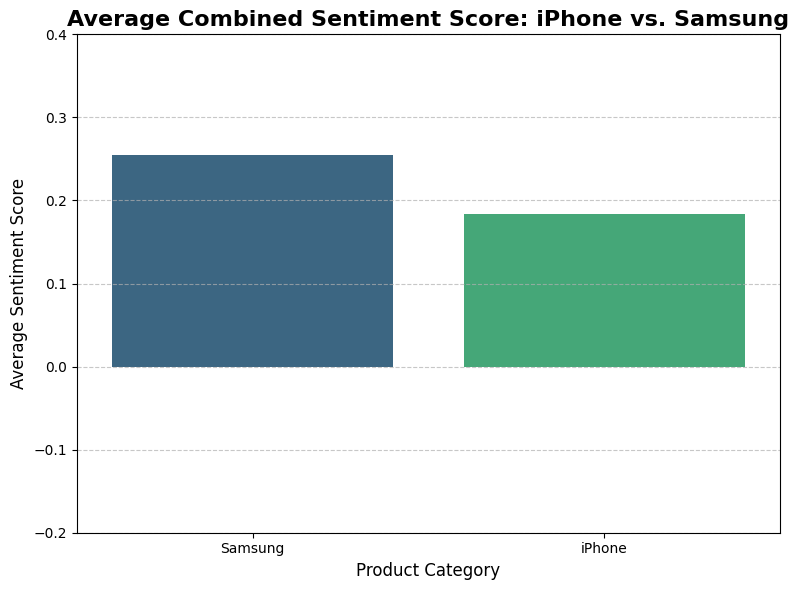

In [ ]:
# Average sentiment comparison
if not comparison_df.empty:
    avg_sentiment_scores = comparison_df.groupby('product_category')['combined_sentiment_score'].mean().reset_index()

    print("\nAverage Combined Sentiment Score for iPhone vs. Samsung:")
    display(avg_sentiment_scores)

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.barplot(x='product_category', y='combined_sentiment_score', data=avg_sentiment_scores, palette='viridis', hue='product_category', legend=False, ax=ax)
    ax.set_title('Average Combined Sentiment Score: iPhone vs. Samsung', fontsize=16, fontweight='bold')
    ax.set_xlabel('Product Category', fontsize=12)
    ax.set_ylabel('Average Sentiment Score', fontsize=12)
    ax.set_ylim([-0.2, 0.4])
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("Comparison DataFrame is empty, cannot calculate average sentiment scores.")